# 02.Preprocess GoEmotions into 7 Balanced Emotions

This notebook prepares the dataset for model training.

1. Load the three raw CSV files.
2. Remove unclear examples.
3. Remove rows with no active emotion label.
4. Map GoEmotions labels into 7 emotions.
5. Split into train, validation, and test sets.
6. Balance only the training set.
7. Save processed CSV files and label mapping.

In [1]:
# Import required libraries
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

## 1. Set paths

In [2]:
# Project root assumes this notebook is inside: project/notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILES = [
    RAW_DATA_DIR / "goemotions_1.csv",
    RAW_DATA_DIR / "goemotions_2.csv",
    RAW_DATA_DIR / "goemotions_3.csv",
]

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

for file_path in RAW_FILES:
    print(file_path.name, "exists:", file_path.exists())

Project root: c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier
Raw data directory: c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\raw
Processed data directory: c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\processed
goemotions_1.csv exists: True
goemotions_2.csv exists: True
goemotions_3.csv exists: True


## 2. Define fixed mapping into 7 emotions

In [3]:
# Fixed 7-emotion label order used throughout the whole project.
# Do NOT change this order after preprocessing, because it controls label_id values.
UI_LABEL_NAMES = ["happy", "calm", "sad", "angry", "anxious", "stressed", "confused"]

# Mapping from GoEmotions labels into 7 UI emotions.
# GoEmotions has 27 emotions + neutral = 28 label columns.
UI_MAPPING = {
    "happy": [
        "admiration", "amusement", "approval", "desire", "excitement",
        "gratitude", "joy", "love", "optimism", "pride"
    ],
    "calm": [
        "neutral", "relief", "caring"
    ],
    "sad": [
        "disappointment", "embarrassment", "grief", "remorse", "sadness"
    ],
    "angry": [
        "anger", "annoyance", "disapproval", "disgust"
    ],
    "anxious": [
        "fear"
    ],
    "stressed": [
        "nervousness"
    ],
    "confused": [
        "confusion", "curiosity", "realization", "surprise"
    ],
}

# Reverse mapping: original emotion -> UI emotion.
GO_TO_UI = {}
for ui_label, original_labels in UI_MAPPING.items():
    for original_label in original_labels:
        GO_TO_UI[original_label] = ui_label

In [4]:
# Save label dictionaries using the fixed order.
label2id = {label: idx for idx, label in enumerate(UI_LABEL_NAMES)}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'happy': 0, 'calm': 1, 'sad': 2, 'angry': 3, 'anxious': 4, 'stressed': 5, 'confused': 6}
id2label: {0: 'happy', 1: 'calm', 2: 'sad', 3: 'angry', 4: 'anxious', 5: 'stressed', 6: 'confused'}


## 3. Load raw dataset

In [5]:
df_list = []

for file_path in RAW_FILES:
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)
    print(f"{file_path.name}: {temp_df.shape}")

df = pd.concat(df_list, ignore_index=True)

print("\nCombined dataset shape:", df.shape)
df.head()

goemotions_1.csv: (70000, 37)
goemotions_2.csv: (70000, 37)
goemotions_3.csv: (71225, 37)

Combined dataset shape: (211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


## 4. Identify emotion columns

In [6]:
metadata_cols = [
    "text", "id", "author", "subreddit", "link_id", "parent_id",
    "created_utc", "rater_id", "example_very_unclear"
]

emotion_cols = [col for col in df.columns if col not in metadata_cols]

print("Number of emotion columns:", len(emotion_cols))
print(emotion_cols)

Number of emotion columns: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


## 5. Clean unreliable rows

In [7]:
print("Before cleaning:", df.shape)

# Remove unclear examples
df = df[df["example_very_unclear"] == False].copy()

# Remove rows without any active emotion label
df["num_active_labels"] = df[emotion_cols].sum(axis=1)
df = df[df["num_active_labels"] > 0].copy()

print("After cleaning:", df.shape)

Before cleaning: (211225, 37)
After cleaning: (207814, 38)


## 6. Convert multi-label GoEmotions rows into one 7-emotion label

In [9]:
import numpy as np

# Create an empty score table.
# Each row = one text sample
# Each column = one final UI emotion
score_df = pd.DataFrame(index=df.index)

for ui_label in UI_LABEL_NAMES:
    original_labels = UI_MAPPING[ui_label]

    # Keep only labels that actually exist in the dataset
    available_labels = [label for label in original_labels if label in df.columns]

    # Sum active GoEmotions labels for each UI emotion group
    score_df[ui_label] = df[available_labels].sum(axis=1)

# Select the UI emotion with the highest score
df["label"] = score_df.idxmax(axis=1)

# Keep only text and final label
processed_df = df[["text", "label"]].copy()

# Remove empty or missing text
processed_df = processed_df.dropna(subset=["text"])
processed_df = processed_df[processed_df["text"].astype(str).str.strip() != ""]

# Add fixed label IDs
processed_df["label_id"] = processed_df["label"].map(label2id)

print("Processed dataset shape:", processed_df.shape)
processed_df.head()

Processed dataset shape: (207814, 3)


,text,label,label_id
0,That game hurt.,sad,2
2,"You do right, if you don't care then fuck 'em!",calm,1
3,Man I love reddit.,happy,0
4,"[NAME] was nowhere near them, he was by the Fa...",calm,1
5,Right? Considering it’s such an important docu...,happy,0


## 7. Check distribution before balancing

,count
label,
happy,77216
calm,60486
sad,16438
angry,29532
anxious,2310
stressed,862
confused,20970


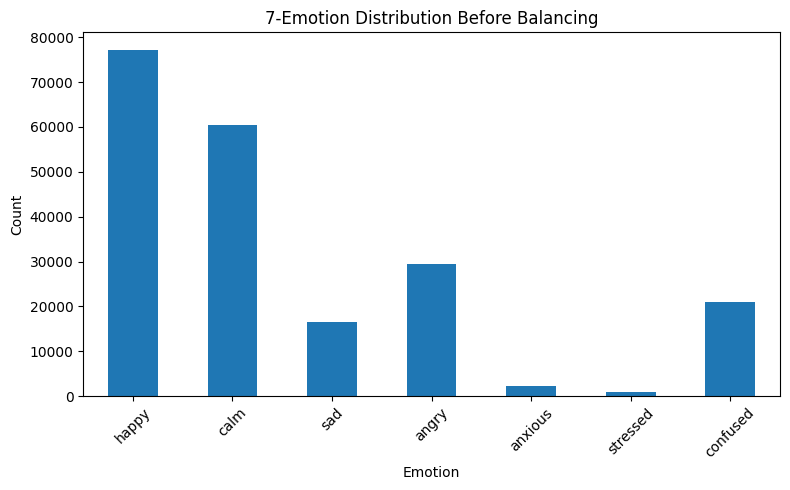

In [10]:
before_counts = processed_df["label"].value_counts().reindex(UI_LABEL_NAMES)

display(before_counts.to_frame(name="count"))

plt.figure(figsize=(8, 5))
before_counts.plot(kind="bar")
plt.title("7-Emotion Distribution Before Balancing")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Split into train, validation, and test sets

In [11]:
# Split before balancing to prevent data leakage.
# Validation and test sets should stay natural/unbalanced.
train_df, temp_df = train_test_split(
    processed_df,
    test_size=0.20,
    stratify=processed_df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (166251, 3)
Validation shape: (20781, 3)
Test shape: (20782, 3)


## 9. Balance only the training set

In [12]:
# Balancing is applied only to the training set.
# This avoids duplicated samples leaking into validation/test data.

# Set a fixed target count to keep training manageable.
# For a stronger model, increase this number.
# For faster CPU training, reduce this number.
TARGET_SAMPLES_PER_CLASS = 2000

balanced_parts = []

for label in UI_LABEL_NAMES:
    class_df = train_df[train_df["label"] == label]

    if len(class_df) == 0:
        raise ValueError(f"No samples found for label: {label}")

    # If class has fewer samples than target, oversample with replacement.
    # If class has more samples than target, undersample without replacement.
    replace_needed = len(class_df) < TARGET_SAMPLES_PER_CLASS

    sampled_df = resample(
        class_df,
        replace=replace_needed,
        n_samples=TARGET_SAMPLES_PER_CLASS,
        random_state=42
    )

    balanced_parts.append(sampled_df)

train_balanced_df = pd.concat(balanced_parts, ignore_index=True)

# Shuffle balanced training data
train_balanced_df = train_balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced train shape:", train_balanced_df.shape)
display(train_balanced_df["label"].value_counts().reindex(UI_LABEL_NAMES).to_frame(name="count"))

Balanced train shape: (14000, 3)


,count
label,
happy,2000
calm,2000
sad,2000
angry,2000
anxious,2000
stressed,2000
confused,2000


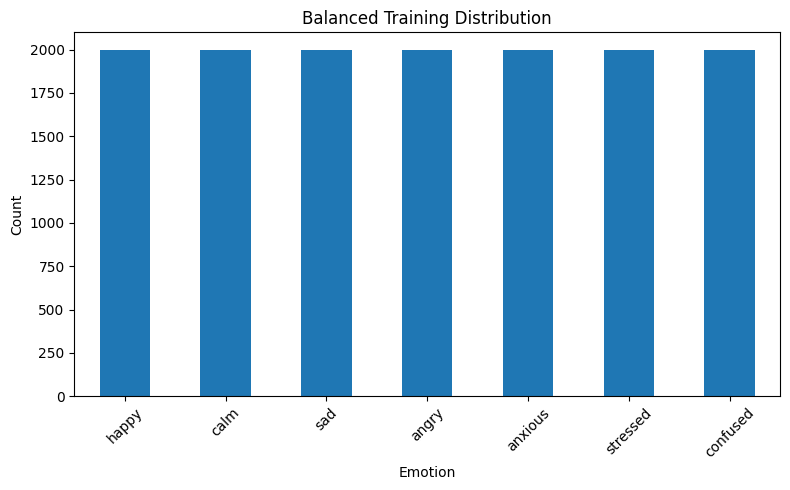

In [13]:
# Visualize balanced training distribution
balanced_counts = train_balanced_df["label"].value_counts().reindex(UI_LABEL_NAMES)

plt.figure(figsize=(8, 5))
balanced_counts.plot(kind="bar")
plt.title("Balanced Training Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Save processed files

In [14]:
# Save processed datasets
train_path = PROCESSED_DATA_DIR / "train.csv"
val_path = PROCESSED_DATA_DIR / "val.csv"
test_path = PROCESSED_DATA_DIR / "test.csv"
label_mapping_path = PROCESSED_DATA_DIR / "label_mapping.json"

train_balanced_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

# Save mapping for future use
label_mapping = {
    "label2id": label2id,
    "id2label": {str(k): v for k, v in id2label.items()},
    "ui_label_names": UI_LABEL_NAMES,
    "ui_mapping": UI_MAPPING,
    "target_samples_per_class": TARGET_SAMPLES_PER_CLASS
}

with open(label_mapping_path, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, indent=4)

print("Saved:")
print(train_path)
print(val_path)
print(test_path)
print(label_mapping_path)

Saved:
c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\processed\train.csv
c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\processed\val.csv
c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\processed\test.csv
c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\processed\label_mapping.json


In [15]:
train_df.head()

,text,label,label_id
87381,Oh dear lord. Imagine if [NAME] scores off the...,calm,1
156629,that's your inferiority complex not ours...you...,calm,1
151352,Now I'm imagining him responding to your dirty...,happy,0
23136,That looks righteous!!,happy,0
164822,Okubo thanks JP/EU for their work over the wee...,happy,0


## Preprocessing Summary

The dataset is now ready for model training.

Generated files:

- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`
- `data/processed/label_mapping.json`

Important note:  
Only the training set was balanced. Validation and test sets were not balanced, so evaluation is more realistic.